# Phase 9.3: Key Figures

This notebook generates the 5 key figures required for the workshop paper submission.

In [1]:
!pip install -r ../requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from scipy.stats import kruskal, mannwhitneyu
import matplotlib.patches as patches
import matplotlib.lines as lines
import os

# Create figures directory if it doesn't exist
os.makedirs("../figures", exist_ok=True)

## Figure 1: Pipeline Figure
Conceptual diagram of the methodology.

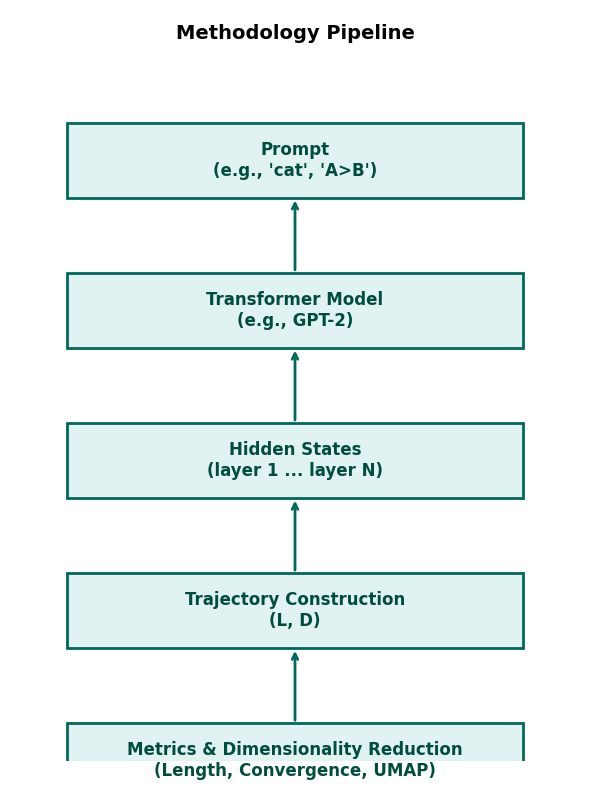

In [3]:
fig, ax = plt.subplots(figsize=(6, 8))
ax.axis('off')

boxes = [
    ("Prompt\n(e.g., 'cat', 'A>B')", 0.8),
    ("Transformer Model\n(e.g., GPT-2)", 0.6),
    ("Hidden States\n(layer 1 ... layer N)", 0.4),
    ("Trajectory Construction\n(L, D)", 0.2),
    ("Metrics & Dimensionality Reduction\n(Length, Convergence, UMAP)", 0.0)
]

for i, (text, y) in enumerate(boxes):
    box = patches.Rectangle((0.1, y - 0.05), 0.8, 0.1, fill=True, color='#e0f2f1', ec='#00695c', lw=2)
    ax.add_patch(box)
    ax.text(0.5, y, text, ha='center', va='center', fontsize=12, fontweight='bold', color='#004d40')
    if i < len(boxes) - 1:
        ax.annotate('', xy=(0.5, y - 0.05), xytext=(0.5, boxes[i+1][1] + 0.05),
                    arrowprops=dict(arrowstyle='->', lw=2, color='#00695c'))
        
plt.title("Methodology Pipeline", fontsize=14, fontweight='bold', y=0.95)
plt.tight_layout()
plt.savefig('../figures/figure1_pipeline.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../figures/figure1_pipeline.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 2: 3D Trajectory Manifold
Visualizes trajectory evolution across layers for Animals, Objects (Vehicles), and Reasoning.

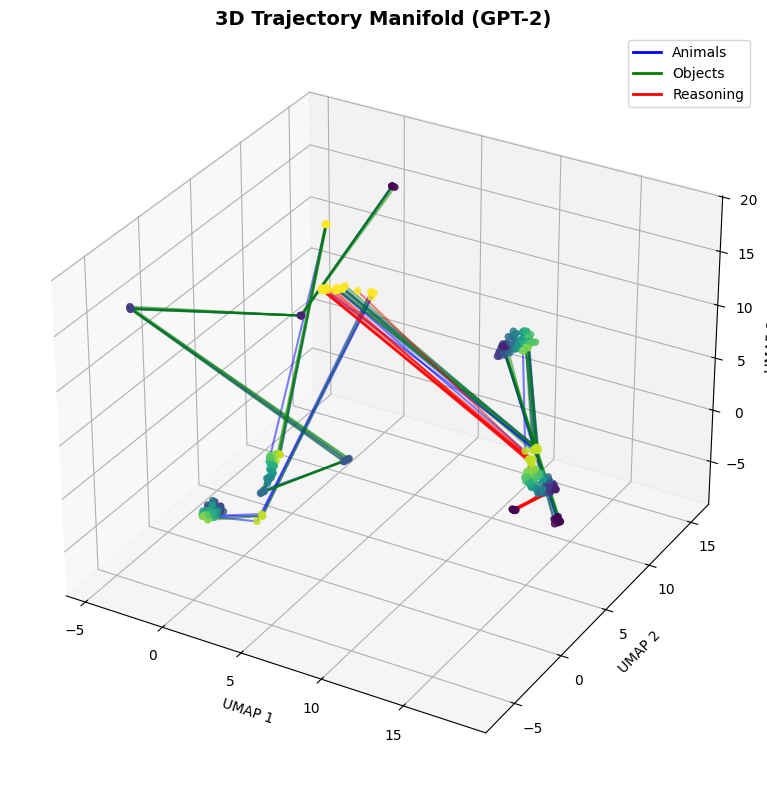

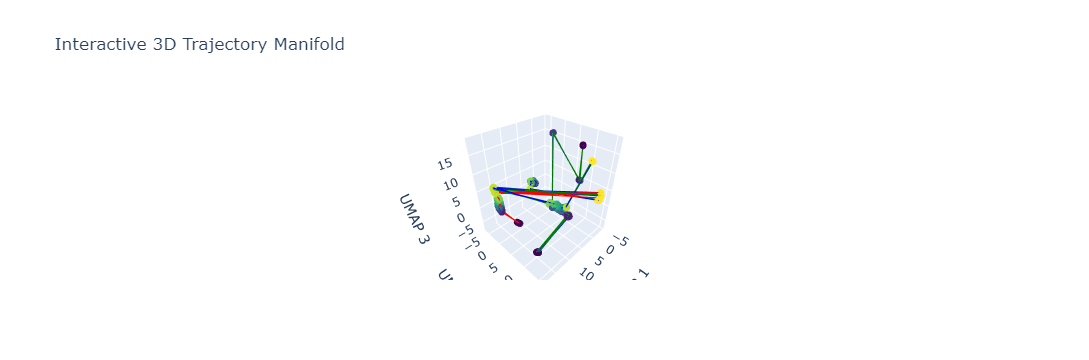

In [4]:
df_umap = pd.read_parquet('../results/projected/gpt2_umap.parquet')
groups_to_plot = ['animals', 'vehicles', 'reasoning']
df_filtered = df_umap[df_umap['group'].isin(groups_to_plot)].copy()
df_filtered['group'] = df_filtered['group'].replace({'vehicles': 'objects'})
color_map = {'animals': 'blue', 'objects': 'green', 'reasoning': 'red'}

# STATIC PLOT (Matplotlib)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for group in color_map.keys():
    group_df = df_filtered[df_filtered['group'] == group]
    for prompt_id in group_df['prompt_id'].unique():
        traj = group_df[group_df['prompt_id'] == prompt_id].sort_values('layer')
        ax.plot(traj['x'], traj['y'], traj['z'], color=color_map[group], alpha=0.5, lw=1.5)
        ax.scatter(traj['x'], traj['y'], traj['z'], c=traj['layer'], cmap='viridis', s=20, alpha=0.8)

legend_elements = [lines.Line2D([0], [0], color=c, lw=2, label=g.capitalize()) for g, c in color_map.items()]
ax.legend(handles=legend_elements, loc='upper right')
ax.set_title("3D Trajectory Manifold (GPT-2)", fontsize=14, fontweight='bold')
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_zlabel("UMAP 3")
plt.tight_layout()
plt.savefig('../figures/figure2_manifold.pdf', dpi=300, bbox_inches='tight')
plt.show()

# INTERACTIVE PLOT (Plotly)
fig_plotly = go.Figure()
for group in color_map.keys():
    group_df = df_filtered[df_filtered['group'] == group]
    for prompt_id in group_df['prompt_id'].unique():
        traj = group_df[group_df['prompt_id'] == prompt_id].sort_values('layer')
        fig_plotly.add_trace(go.Scatter3d(
            x=traj['x'], y=traj['y'], z=traj['z'],
            mode='lines+markers',
            line=dict(color=color_map[group], width=2),
            marker=dict(size=4, color=traj['layer'], colorscale='Viridis', opacity=0.8),
            name=f"{group} - {prompt_id}",
            showlegend=False
        ))
fig_plotly.update_layout(title="Interactive 3D Trajectory Manifold", scene=dict(xaxis_title='UMAP 1', yaxis_title='UMAP 2', zaxis_title='UMAP 3'))
fig_plotly.write_html('../figures/trajectory.html')
fig_plotly.show()

## Figure 3: Convergence Metric
Analyzes layerwise within-category vs between-category Euclidean distances in PCA space.

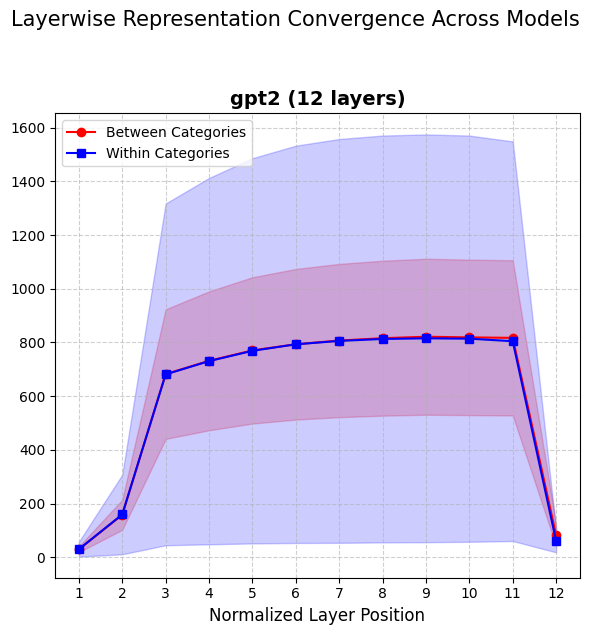

In [5]:
import glob, os
projected_dir = '../results/projected'
projected_files = sorted(glob.glob(os.path.join(projected_dir, '*_pca.parquet')))
if not projected_files:
    raise FileNotFoundError(f'No PCA projection files found in {projected_dir}')
fig, axes = plt.subplots(1, len(projected_files), figsize=(6 * len(projected_files), 6), sharey=True)
if len(projected_files) == 1:
    axes = [axes]
categories = ['animals', 'vehicles', 'reasoning']
for ax, proj_path in zip(axes, projected_files):
    model_name = os.path.basename(proj_path).replace('_pca.parquet', '')
    df_pca = pd.read_parquet(proj_path)
    layers = sorted(df_pca['layer'].unique())
    within_distances = []
    between_distances = []
    for l in layers:
        df_l = df_pca[df_pca['layer'] == l]
        centroids = {}
        for cat in categories:
            cat_data = df_l[df_l['group'] == cat][['x', 'y', 'z']].values
            if len(cat_data) > 0:
                centroid = np.mean(cat_data, axis=0)
                centroids[cat] = centroid
                dists = np.linalg.norm(cat_data - centroid, axis=1)
                for d in dists:
                    within_distances.append({'layer': l, 'distance': float(d), 'type': 'Within Category'})
        cat_keys = list(centroids.keys())
        for i2 in range(len(cat_keys)):
            for j2 in range(i2 + 1, len(cat_keys)):
                d = np.linalg.norm(centroids[cat_keys[i2]] - centroids[cat_keys[j2]])
                between_distances.append({'layer': l, 'distance': float(d), 'type': 'Between Category'})
    df_within = pd.DataFrame(within_distances)
    df_between = pd.DataFrame(between_distances)
    if df_within.empty or df_between.empty:
        raise ValueError(f'Not enough data for model {model_name} to compute convergence metrics.')
    within_mean = df_within.groupby('layer')['distance'].mean().reindex(layers).fillna(0).values
    within_std = df_within.groupby('layer')['distance'].std(ddof=0).reindex(layers).fillna(0).values
    between_mean = df_between.groupby('layer')['distance'].mean().reindex(layers).fillna(0).values
    between_std = df_between.groupby('layer')['distance'].std(ddof=0).reindex(layers).fillna(0).values
    x_norm = np.linspace(0, 1, len(layers))
    ax.plot(x_norm, between_mean, label='Between Categories', color='red', marker='o')
    ax.fill_between(x_norm, between_mean - between_std, between_mean + between_std, color='red', alpha=0.2)
    ax.plot(x_norm, within_mean, label='Within Categories', color='blue', marker='s')
    ax.fill_between(x_norm, within_mean - within_std, within_mean + within_std, color='blue', alpha=0.2)
    ax.set_title(f'{model_name} ({len(layers)} layers)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Normalized Layer Position', fontsize=12)
    ax.set_xticks(x_norm)
    ax.set_xticklabels(layers)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()
fig.suptitle('Layerwise Representation Convergence Across Models', fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig('../figures/figure3_convergence.pdf', dpi=300)
plt.show()


## Figure 4: Curvature Analysis
Compares non-linearity of trajectories across specific categories.

<>:12: SyntaxWarning: invalid escape sequence '\k'
<>:12: SyntaxWarning: invalid escape sequence '\k'
C:\Users\bisha\AppData\Local\Temp\ipykernel_33032\2288065810.py:12: SyntaxWarning: invalid escape sequence '\k'
  ax.set_ylabel("Curvature ($\kappa$)")


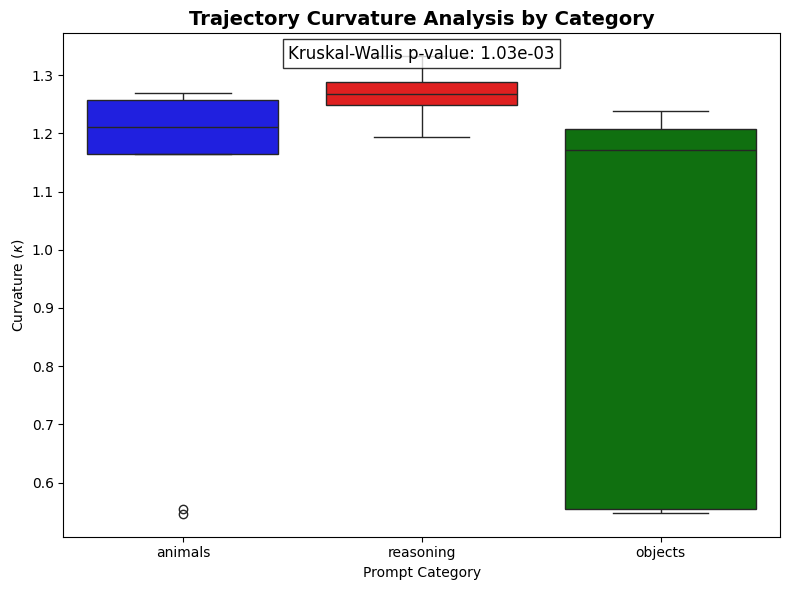

In [6]:
df_metrics = pd.read_csv('../results/metrics/phase_7_controls_metrics/gpt2_trajectory_metrics.csv')
df_plot = df_metrics[df_metrics['category'].isin(['animals', 'vehicles', 'reasoning'])].copy()
df_plot['category'] = df_plot['category'].replace({'vehicles': 'objects'})

groups = [df_plot[df_plot['category'] == cat]['curvature'].values for cat in df_plot['category'].unique()]
stat, p_val = kruskal(*groups)

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x='category', y='curvature', data=df_plot, ax=ax, hue='category', palette={'animals': 'blue', 'objects': 'green', 'reasoning': 'red'}, legend=False)
ax.set_title("Trajectory Curvature Analysis by Category", fontsize=14, fontweight='bold')
ax.set_xlabel("Prompt Category")
ax.set_ylabel("Curvature ($\kappa$)")
ax.text(0.5, 0.95, f"Kruskal-Wallis p-value: {p_val:.2e}" + (" (***)" if p_val < 0.001 else ""), 
        transform=ax.transAxes, ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('../figures/figure4_curvature.pdf', dpi=300)
plt.show()

## Figure 5: Control Experiments
Validates trajectory structure against label shuffling, random embeddings, and layer shuffling.

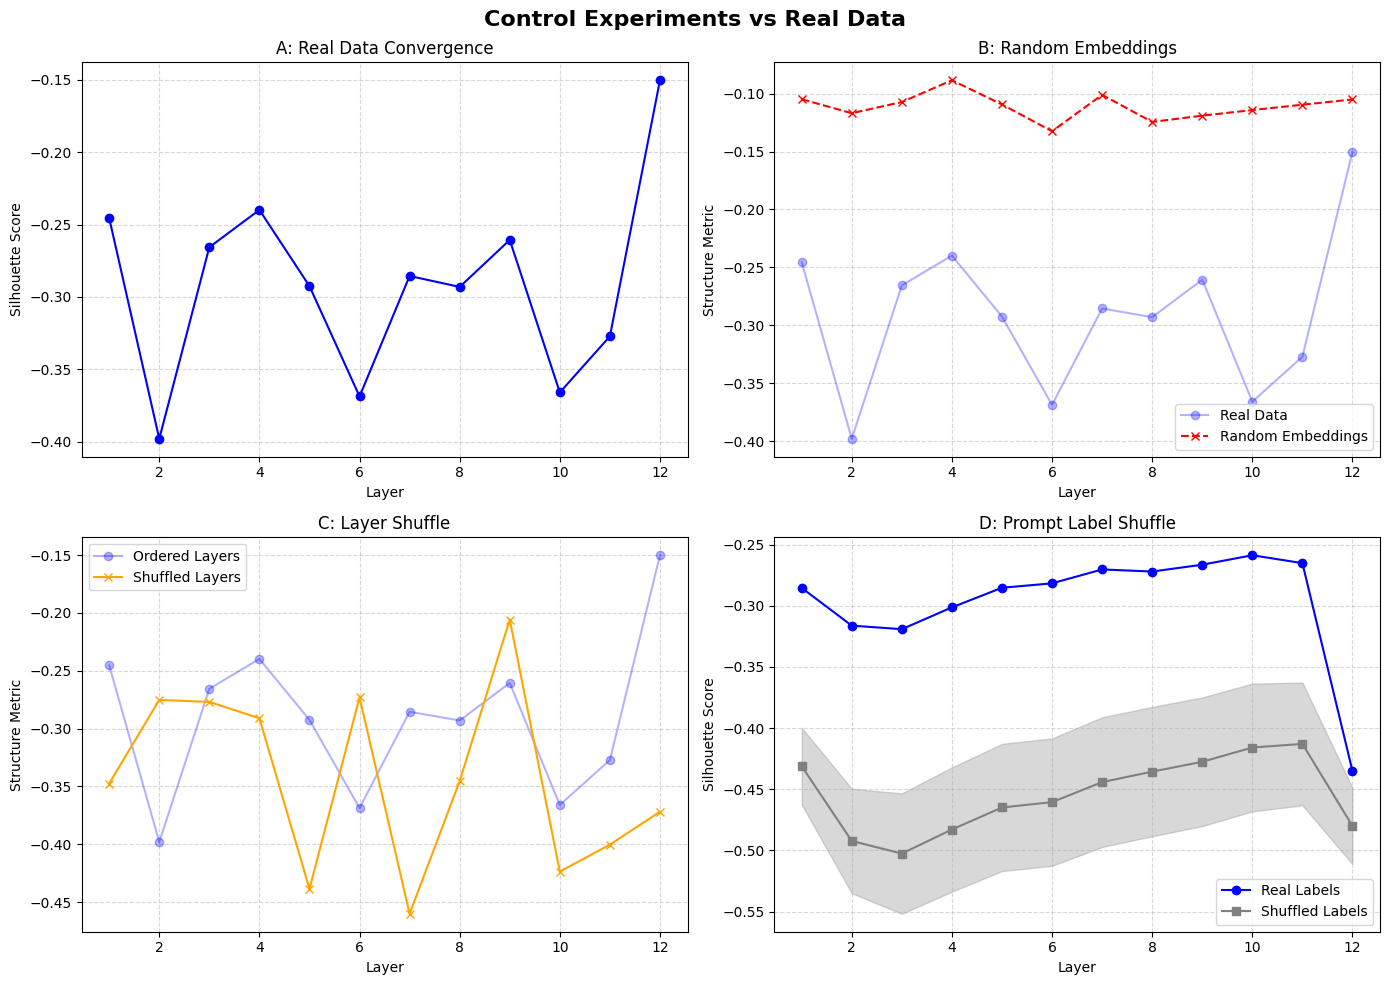

In [7]:
df_shuffle = pd.read_csv('../results/controls/gpt2_label_shuffle.csv')
df_real = pd.read_csv('../results/controls/gpt2_real_silhouette.csv')
df_rand = pd.read_csv('../results/controls/gpt2_random_embeddings.csv')
df_layer_shuffle = pd.read_csv('../results/controls/gpt2_layer_shuffle.csv')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Control Experiments vs Real Data", fontsize=16, fontweight='bold')

axes[0, 0].plot(df_real['layer'], df_real['score'], marker='o', color='blue', label='Real Data')
axes[0, 0].set_title("A: Real Data Convergence")
axes[0, 0].set_xlabel("Layer")
axes[0, 0].set_ylabel("Silhouette Score")
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

axes[1, 1].plot(df_shuffle['layer'], df_shuffle['real_score'], marker='o', color='blue', label='Real Labels')
axes[1, 1].plot(df_shuffle['layer'], df_shuffle['null_mean'], marker='s', color='grey', label='Shuffled Labels')
axes[1, 1].fill_between(df_shuffle['layer'], df_shuffle['null_mean'] - df_shuffle['null_std'], df_shuffle['null_mean'] + df_shuffle['null_std'], color='grey', alpha=0.3)
axes[1, 1].set_title("D: Prompt Label Shuffle")
axes[1, 1].set_xlabel("Layer")
axes[1, 1].set_ylabel("Silhouette Score")
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

axes[0, 1].plot(df_real['layer'], df_real['score'], marker='o', color='blue', label='Real Data', alpha=0.3)
axes[0, 1].plot(df_rand['layer'], df_rand['score'], marker='x', color='red', linestyle='--', label='Random Embeddings')
axes[0, 1].set_title("B: Random Embeddings")
axes[0, 1].set_xlabel("Layer")
axes[0, 1].set_ylabel("Structure Metric")
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

axes[1, 0].plot(df_real['layer'], df_real['score'], marker='o', color='blue', label='Ordered Layers', alpha=0.3)
axes[1, 0].plot(df_layer_shuffle['layer'], df_layer_shuffle['score'], marker='x', color='orange', label='Shuffled Layers')
axes[1, 0].set_title("C: Layer Shuffle")
axes[1, 0].set_xlabel("Layer")
axes[1, 0].set_ylabel("Structure Metric")
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../figures/figure5_controls.pdf', dpi=300)
plt.show()